In [1]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
from scipy.sparse import issparse
from pathlib import Path
import numpy as np
import scvelo as scv
# os.chdir("/mnt/e/project/Benchmark_velocity/revision/batch")
# os.getcwd()

In [2]:
data_dir = "/mnt/f/velocity_dataset_e/dataset/"
fig_dir = "./figs/"
os.makedirs(fig_dir, exist_ok=True)

# batch figure

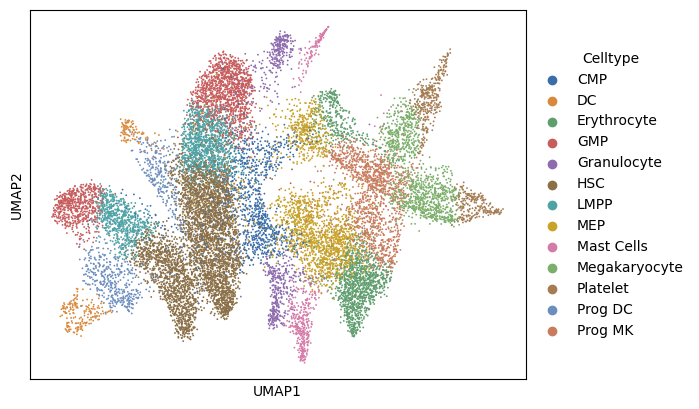

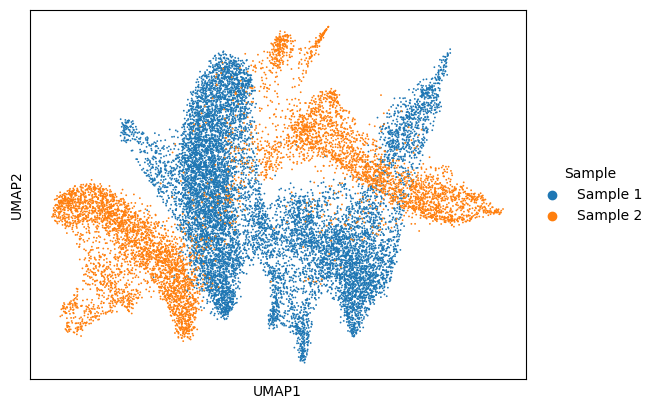

In [3]:
dataset = 'HSPCs'
adata = sc.read_h5ad(f'{data_dir}/{dataset}/raw/HSPCs.h5ad')

leiden_colors = [
    "#3B6EA8",
    "#D9893D",
    "#5F9E6E",
    "#C85C5C",
    "#8E6BAE",
    "#8B6F47",
    "#4FA3A5",
    "#C9A227",
    "#D67BA8",
    "#7BAF6A",
    "#A67C52",
    "#6C8EBF",
    "#C97C5D",
]
ax = sc.pl.umap(
    adata,
    color="leiden",
    title="",
    palette=leiden_colors,
    show=False
)
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Celltype")

plt.savefig(f"{fig_dir}{dataset}_raw_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close() 

ax = sc.pl.umap(
    adata,
    color="batch",
    title="",
    show=False
)
legend = ax.get_legend()
if legend is not None:
    legend.set_title("Sample")
plt.savefig(f"{fig_dir}{dataset}_raw_sample.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

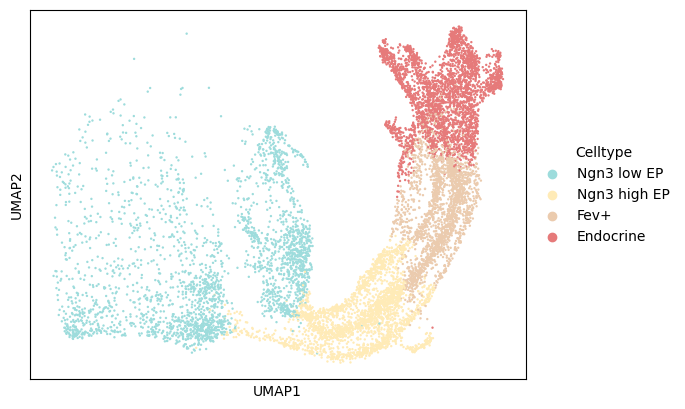

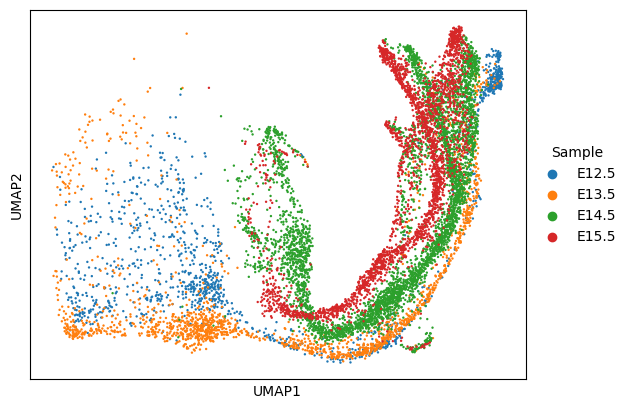

In [4]:
import pandas as pd

dataset = 'pan4time'
adata = sc.read_h5ad(f'{data_dir}/{dataset}/raw/pan4time.h5ad.h5')

adata = adata[
    adata.obs['clusters_fig3_final'].isin(['Ngn3 low EP', 'Ngn3 high EP', 'Fev+', 'Endocrine'])
].copy()

adata.obs = adata.obs[['day', 'clusters_fig3_final']].copy()
adata.obs.rename(columns={'clusters_fig3_final': 'celltype'}, inplace=True)

# 12.5 -> E12.5
adata.obs['day'] = adata.obs['day'].apply(lambda x: f"E{x:g}" if isinstance(x, (int, float)) else f"E{x}")

# 可选：固定 legend 顺序
adata.obs['day'] = pd.Categorical(
    adata.obs['day'],
    categories=['E12.5', 'E13.5', 'E14.5', 'E15.5'],
    ordered=True
)

adata.uns = {}

celltype_colors = [
    "#9ddcdc", "#ffebb7", "#ebcbae", "#e67a7a"
]

ax = sc.pl.umap(
    adata,
    color="celltype",
    title="",
    palette=celltype_colors,
    show=False
)

legend = ax.get_legend()
if legend is not None:
    legend.set_title("Celltype")

plt.savefig(f"{fig_dir}{dataset}_raw_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


ax = sc.pl.umap(
    adata,
    color="day",
    title="",
    show=False
)

legend = ax.get_legend()
if legend is not None:
    legend.set_title("Sample")

plt.savefig(f"{fig_dir}{dataset}_raw_sample.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# LantentVelo embedding

In [5]:
cluster_key = 'leiden'
batch_key = 'batch'
dataset = 'HSPCs'
method = 'latentvelo_std'
vkey = f"{method}_velocity"
adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")

sc.pp.neighbors(
    adata,
    use_rep="X",
    n_neighbors=30,
    random_state=1234
)
sc.tl.umap(adata, random_state=1234)

In [6]:
sc.pl.umap(adata, color=cluster_key, title='Cluster',show=False)
plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_cluster.png", dpi=150, bbox_inches="tight")
plt.close()

sc.pl.umap(adata, color=batch_key, title='Batch',show=False)
plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_batch.png", dpi=150, bbox_inches="tight")
plt.close() 

In [23]:
cluster_key = 'celltype'
batch_key = 'day'
dataset = 'pan4time'
method = 'latentvelo_std'
vkey = f"{method}_velocity"
adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")

sc.pp.neighbors(
    adata,
    use_rep="X",
    n_neighbors=30,
    random_state=1234
)
sc.tl.umap(adata, random_state=1234)

In [24]:
sc.pl.umap(adata, color=cluster_key, title='Cluster',show=False)
plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_cluster.png", dpi=150, bbox_inches="tight")
plt.close()

sc.pl.umap(adata, color=batch_key, title='Batch',show=False)
plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_batch.png", dpi=150, bbox_inches="tight")
plt.close() 

# scTour embedding

In [7]:
cluster_key = 'leiden'
batch_key = 'batch'
dataset = 'HSPCs'
adatas = []
for method in ['sctour_mse', 'sctour_nb', 'sctour_zinb']:
    vkey = f"{method}_velocity"
    adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")

    sc.pp.neighbors(
            adata,
            use_rep="X_TNODE",
            n_neighbors=30,
            random_state=1234
            )
    sc.tl.umap(adata, random_state=1234)

    adatas.append(adata)

In [8]:
for i in range(len(adatas)):
    adata = adatas[i]
    method = ['sctour_mse', 'sctour_nb', 'sctour_zinb'][i]
    sc.pl.umap(adata, color=cluster_key, title='Cluster',show=False)
    plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_cluster.png", dpi=150, bbox_inches="tight")
    plt.close()

    sc.pl.umap(adata, color=batch_key, title='Batch',show=False)
    plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_batch.png", dpi=150, bbox_inches="tight")
    plt.close()

In [28]:
cluster_key = 'celltype'
batch_key = 'day'
dataset = 'pan4time'
adatas = []
for method in ['sctour_mse', 'sctour_nb', 'sctour_zinb']:
    vkey = f"{method}_velocity"
    adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method}_full.h5ad")

    sc.pp.neighbors(
            adata,
            use_rep="X_TNODE",
            n_neighbors=30,
            random_state=1234
            )
    sc.tl.umap(adata, random_state=1234)

    adatas.append(adata)

In [29]:
for i in range(len(adatas)):
    adata = adatas[i]
    method = ['sctour_mse', 'sctour_nb', 'sctour_zinb'][i]
    sc.pl.umap(adata, color=cluster_key, title='Cluster',show=False)
    plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_cluster.png", dpi=150, bbox_inches="tight")
    plt.close()

    sc.pl.umap(adata, color=batch_key, title='Batch',show=False)
    plt.savefig(f"{fig_dir}{dataset}_{method}_embedding_batch.png", dpi=150, bbox_inches="tight")
    plt.close()

# batch effects 指标

In [5]:
from scib_metrics.benchmark import Benchmarker

## HSPCs

In [6]:
dataset = 'HSPCs'
cluster_key = 'leiden'
batch_key = 'batch'
adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_preprocessed_full.h5ad")

In [7]:
methods = ['latentvelo_std', 'sctour_mse', 'sctour_nb', 'sctour_zinb']
method_names = ['LatentVelo (std)', 'scTour (MSE)', 'scTour (NB)', 'scTour (ZINB)']
for i in range(len(methods)):

    method_i = methods[i]
    method_name = method_names[i]
    adata_method = sc.read_h5ad(
        Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method_i}_full.h5ad"
    )

    # 1. 先检查细胞集合是否一致
    if not adata.obs_names.isin(adata_method.obs_names).all():
        missing = adata.obs_names[~adata.obs_names.isin(adata_method.obs_names)]
        raise ValueError(f"{method_name} 缺少这些细胞: {list(missing[:10])}")

    if not adata_method.obs_names.isin(adata.obs_names).all():
        extra = adata_method.obs_names[~adata_method.obs_names.isin(adata.obs_names)]
        raise ValueError(f"{method_name} 多出这些细胞: {list(extra[:10])}")

    # 2. 按 adata 的顺序重排
    adata_method = adata_method[adata.obs_names].copy()

    if method_i == 'latentvelo_std':
        # 3. latentvelo_std 的 embedding 在 X 中
        adata.obsm[f"{method_name}"] = adata_method.X
    else:
        # 3. sctour 的 embedding 在 X_TNODE 中
        adata.obsm[f"{method_name}"] = adata_method.obsm['X_TNODE']
   


In [8]:
adata.obsm['PCA'] = adata.obsm['X_pca']
adata.obsm['Harmony'] = adata.obsm['X_pca_harmony']
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=cluster_key,
    embedding_obsm_keys=["PCA", "Harmony", 'LatentVelo (std)', 'scTour (MSE)', 'scTour (NB)', 'scTour (ZINB)'],
    n_jobs=8,
)
bm.benchmark()

Embeddings: 100%|██████████| 6/6 [01:27<00:00, 14.64s/it]


In [9]:
bm.plot_results_table(min_max_scale=False,show=False)
plt.savefig(f"{fig_dir}{dataset}_batch_effects.png", dpi=150, bbox_inches="tight")
plt.close() 

## pan4time

In [10]:
import scanpy as sc

dataset = 'pan4time'
cluster_key = 'celltype'
batch_key = 'day'
adata = sc.read_h5ad(Path(data_dir) / f'{dataset}/processed' / f"adata_preprocessed_full.h5ad")

In [11]:
methods = ['latentvelo_std', 'sctour_mse', 'sctour_nb', 'sctour_zinb']
method_names = ['LatentVelo (std)', 'scTour (MSE)', 'scTour (NB)', 'scTour (ZINB)']
for i in range(len(methods)):

    method_i = methods[i]
    method_name = method_names[i]
    adata_method = sc.read_h5ad(
        Path(data_dir) / f'{dataset}/processed' / f"adata_run_{method_i}_full.h5ad"
    )

    # 1. 先检查细胞集合是否一致
    if not adata.obs_names.isin(adata_method.obs_names).all():
        missing = adata.obs_names[~adata.obs_names.isin(adata_method.obs_names)]
        raise ValueError(f"{method_name} 缺少这些细胞: {list(missing[:10])}")

    if not adata_method.obs_names.isin(adata.obs_names).all():
        extra = adata_method.obs_names[~adata_method.obs_names.isin(adata.obs_names)]
        raise ValueError(f"{method_name} 多出这些细胞: {list(extra[:10])}")

    # 2. 按 adata 的顺序重排
    adata_method = adata_method[adata.obs_names].copy()

    if method_i == 'latentvelo_std':
        # 3. latentvelo_std 的 embedding 在 X 中
        adata.obsm[f"{method_name}"] = adata_method.X
    else:
        # 3. sctour 的 embedding 在 X_TNODE 中
        adata.obsm[f"{method_name}"] = adata_method.obsm['X_TNODE']
   


In [12]:
adata.obsm['PCA'] = adata.obsm['X_pca']
adata.obsm['Harmony'] = adata.obsm['X_pca_harmony']
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=cluster_key,
    embedding_obsm_keys=["PCA", "Harmony", 'LatentVelo (std)', 'scTour (MSE)', 'scTour (NB)', 'scTour (ZINB)'],
    n_jobs=8,
)
bm.benchmark()

Embeddings: 100%|██████████| 6/6 [00:51<00:00,  8.62s/it]


In [13]:
bm.plot_results_table(min_max_scale=False,show=False)
plt.savefig(f"{fig_dir}{dataset}_batch_effects.png", dpi=150, bbox_inches="tight")
plt.close() 